# iPhone Data Cleaning
**Input:** `output/Iphone_database.csv`  
**Output:** `output/Iphone_Database_filtered_train.csv`

Pipeline 8 bước:
1. Import & Cấu hình
2. Load dữ liệu
3. Schema Mapping (27 cột → 10 cột nội bộ)
4. Numeric Conversion (Dung lượng, Giá, Pin, Ngoại hình)
5. Feature Engineering (Tinh_trang_tong_hop, encode binary)
6. Predictive Imputation (RandomForest điền Pin thiếu)
7. Filter & Outlier Removal (IQR + Z-score)
8. Pin_bucket & Export CSV

In [1]:
# ============================================================
#  CELL 1 — Import thư viện & cấu hình đường dẫn
# ============================================================
# !pip install pandas numpy scipy scikit-learn matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.0f}'.format)

INPUT_PATH  = 'output/Iphone_database.csv'
OUTPUT_PATH = 'output/Iphone_Database_filtered_train.csv'

print('Libraries loaded')
print(f'Input : {INPUT_PATH}')
print(f'Output: {OUTPUT_PATH}')

Libraries loaded
Input : output/Iphone_database.csv
Output: output/Iphone_Database_filtered_train.csv


In [2]:
# ============================================================
#  CELL 2 — Load & Inspect
# ============================================================
df_raw = pd.read_csv(INPUT_PATH, encoding='utf-8-sig')

print(f'Shape: {df_raw.shape[0]:,} hang x {df_raw.shape[1]} cot')
print('\nNull report:')
null_report = df_raw.isnull().sum()
print(null_report[null_report > 0].to_string())

df_raw.head(3)

Shape: 1,862 hang x 27 cot

Null report:
Phiên bản               390
Xuất xứ                 756
Màu sắc                  41
Dung lượng               55
Chính sách bảo hành     865
Giá                       1
Tình trạng pin          961
Ngoại hình             1302
Độ zin                  888
Ngoại hình (Title)     1674
Ngoại hình (Detail)    1331
Độ zin (Title)         1701
Độ zin (Detail)         860


,Tiêu đề,Tình trạng,Dòng máy,Phiên bản,Xuất xứ,Màu sắc,Dung lượng,Chính sách bảo hành,Giá,Tình trạng pin,Ngoại hình,Độ zin,ID tin,Link,Mô tả chi tiết,Phiên bản (Source),Xuất xứ (Source),Màu sắc (Source),Dung lượng (Source),Chính sách bảo hành (Source),Tình trạng pin (Source),Ngoại hình (Title),Ngoại hình (Detail),Ngoại hình (Conflict),Độ zin (Title),Độ zin (Detail),Độ zin (Conflict)
0,iPhone 12 Pro 256GB Xanh 99%,Đã sử dụng (chưa sửa chữa),iPhone 12 Pro,Quốc tế (Không khoá mạng),Đài Loan,Xám / Space Gray,512 GB,NaN,"9,000,000",99%,99%,NaN,132228615,https://www.chotot.com/132228615.htm,Nhà dư cần bán điện thoại iPhone 12 Pro 256GB ...,P,P,P,P,FALSE,False,99%,99%,False,NaN,NaN,False
1,Apple iPhone 15 128GB Xanh LL/A,Đã sử dụng (chưa sửa chữa),iPhone 15,Quốc tế (Không khoá mạng),Mỹ (LL/A),Xám / Space Gray,128 GB,Còn bảo hành,"12,300,000",NaN,NaN,Zin nguyên bản,132228588,https://www.chotot.com/132228588.htm,IPHONE 15 XANH DƯƠNG NHẠT 128GB bản LL/A (Mỹ)...,P,P,P,P,P,False,NaN,NaN,False,NaN,Zin nguyên bản,False
2,Apple iPhone 15 pro 128G sạc 3 lần chưa dùng,Mới,iPhone 15 Pro,Quốc tế (Không khoá mạng),Trung Quốc,Xám / Space Gray,128 GB,Hết bảo hành,"15,990,000",100%,NaN,"Zin nguyên bản, Zin áp suất, Ốc zin",132032341,https://www.chotot.com/132032341.htm,Iphone 15 Pro 128G sạc 3 lần duy trì chưa sử d...,P,P,P,P,P,False,NaN,NaN,False,NaN,"Zin nguyên bản, Zin áp suất, Ốc zin",False


In [3]:
# ============================================================
#  CELL 3 — Schema Mapping
#  Chon 10 cot can thiet tu 27 cot → ten noi bo
# ============================================================
REAL_MAP = {
    'Dong may'           : 'Model',
    'Gia'                : 'Gia_VND',
    'Dung luong'         : 'Dung_luong_raw',
    'Tinh trang pin'     : 'Pin_raw',
    'Ngoai hinh (Detail)': 'Ngoaihinh_raw',
    'Do zin (Detail)'    : 'Dozin_raw',
    'Phien ban'          : 'Phien_ban',
    'Xuat xu'            : 'Xuat_xu',
    'Tinh trang'         : 'Tinh_trang',
    'Chinh sach bao hanh': 'Bao_hanh',
}
# Cot thuc te trong file (co dau tieng Viet)
REAL_MAP_VN = {
    'Dong may'           : 'Dòng máy',
    'Gia'                : 'Giá',
    'Dung luong'         : 'Dung lượng',
    'Tinh trang pin'     : 'Tình trạng pin',
    'Ngoai hinh (Detail)': 'Ngoại hình (Detail)',
    'Do zin (Detail)'    : 'Độ zin (Detail)',
    'Phien ban'          : 'Phiên bản',
    'Xuat xu'            : 'Xuất xứ',
    'Tinh trang'         : 'Tình trạng',
    'Chinh sach bao hanh': 'Chính sách bảo hành',
}
col_map = {}
for ascii_key, dst in REAL_MAP.items():
    vn_key = REAL_MAP_VN[ascii_key]
    if vn_key in df_raw.columns:
        col_map[vn_key] = dst

df = df_raw[[c for c in col_map]].rename(columns=col_map).copy()
print(f'Cols sau mapping: {list(df.columns)}')
print(f'Shape: {df.shape}')
df.head(3)

Cols sau mapping: ['Model', 'Gia_VND', 'Dung_luong_raw', 'Pin_raw', 'Ngoaihinh_raw', 'Dozin_raw', 'Phien_ban', 'Xuat_xu', 'Tinh_trang', 'Bao_hanh']
Shape: (1862, 10)


,Model,Gia_VND,Dung_luong_raw,Pin_raw,Ngoaihinh_raw,Dozin_raw,Phien_ban,Xuat_xu,Tinh_trang,Bao_hanh
0,iPhone 12 Pro,"9,000,000",512 GB,99%,99%,NaN,Quốc tế (Không khoá mạng),Đài Loan,Đã sử dụng (chưa sửa chữa),NaN
1,iPhone 15,"12,300,000",128 GB,NaN,NaN,Zin nguyên bản,Quốc tế (Không khoá mạng),Mỹ (LL/A),Đã sử dụng (chưa sửa chữa),Còn bảo hành
2,iPhone 15 Pro,"15,990,000",128 GB,100%,NaN,"Zin nguyên bản, Zin áp suất, Ốc zin",Quốc tế (Không khoá mạng),Trung Quốc,Mới,Hết bảo hành


In [4]:
# ============================================================
#  CELL 4 — Numeric Conversion
# ============================================================

def normalize_model(s):
    if not isinstance(s, str): return 'Unknown'
    s = s.strip()
    s = re.sub(r'(?i)^iphone', 'iPhone', s)
    return s

def parse_dungluong(s):
    '''"128 GB" → 128.0 | "1 TB" → 1024.0'''
    if not isinstance(s, str): return np.nan
    m = re.search(r'([\d]+(?:\.[\d]+)?)', s.lower())
    if not m: return np.nan
    val = float(m.group(1))
    return val * 1024 if 'tb' in s.lower() else val

def parse_pin(s):
    '''"84%" → 84.0 | "Pin khoe" → NaN (se impute)'''
    if not isinstance(s, str): return np.nan
    m = re.search(r'(\d{2,3}(?:\.\d)?)\s*%', s)
    if m:
        v = float(m.group(1))
        return v if 50 <= v <= 100 else np.nan
    return np.nan

def parse_ngoaihinh(s):
    '''"98%" → 98.0 | "Khong tray xuoc" → 99.0'''
    if not isinstance(s, str) or s.strip().upper() in ('', 'FALSE', 'NULL'):
        return np.nan
    sl = s.lower().strip()
    m = re.search(r'(\d{2,3}(?:\.\d)?)\s*%', sl)
    if m:
        v = float(m.group(1))
        return v if 50 <= v <= 100 else np.nan
    if any(kw in sl for kw in ['khong tray', 'keng', 'like new', 'không trầy']):
        return 99.0
    if 'tray nhe' in sl or 'xuoc nhe' in sl or 'trầy nhẹ' in sl:
        return 97.0
    return np.nan

df['Model']           = df['Model'].apply(normalize_model)
df['Dung_luong_GB']   = df['Dung_luong_raw'].apply(parse_dungluong)
df['Tinh_Trang_Pin']  = df['Pin_raw'].apply(parse_pin)
df['Ngoai_hinh']      = df['Ngoaihinh_raw'].apply(parse_ngoaihinh)
df['Gia_VND']         = pd.to_numeric(df['Gia_VND'], errors='coerce')

print('Numeric conversion:')
print(f'  Dung_luong_GB  notna: {df["Dung_luong_GB"].notna().sum()} / {len(df)}')
print(f'  Tinh_Trang_Pin notna: {df["Tinh_Trang_Pin"].notna().sum()} / {len(df)}')
print(f'  Ngoai_hinh     notna: {df["Ngoai_hinh"].notna().sum()} / {len(df)}')
print(f'  Gia_VND        notna: {df["Gia_VND"].notna().sum()} / {len(df)}')

Numeric conversion:
  Dung_luong_GB  notna: 1807 / 1862
  Tinh_Trang_Pin notna: 704 / 1862
  Ngoai_hinh     notna: 521 / 1862
  Gia_VND        notna: 1861 / 1862


In [5]:
# ============================================================
#  CELL 5 — Feature Engineering
#  - Phien_ban_enc: Quoc te=1, Lock=0
#  - Do_Zin_binary: Zin=1, Thay linh kien=0
#  - Tinh_trang_tong_hop: nhan tong hop tinh trang may
# ============================================================

def encode_phienban(s):
    if not isinstance(s, str): return 0
    v = s.lower()
    return 1 if ('không khoá' in v or 'quốc tế' in v or 'khong khoa' in v) else 0

def encode_dozin_binary(dozin_detail, tinh_trang):
    if isinstance(tinh_trang, str) and 'sửa chữa' in tinh_trang.lower():
        return 0
    if not isinstance(dozin_detail, str): return 1
    dl = dozin_detail.lower()
    if any(kw in dl for kw in ['màn thay', 'pin thay', 'cam thay', 'ép kính', 'màn oled']):
        return 0
    return 1

def build_tong_hop(row):
    dozin = str(row.get('Dozin_raw', '')) if isinstance(row.get('Dozin_raw'), str) else ''
    tt    = str(row.get('Tinh_trang', '')) if isinstance(row.get('Tinh_trang'), str) else ''
    d = dozin.lower()
    t = tt.lower()

    if 'mới' in t or t.strip() == 'moi':
        return 'Zin không trầy xước'

    if 'sửa chữa' in t or 'thay linh kiện' in t:
        parts = []
        if any(k in d for k in ['màn thay', 'màn oled', 'ép kính', 'màn linh kiện', 'màn jk', 'màn gx']):
            parts.append('Màn thay')
        if 'pin thay' in d:
            parts.append('Pin thay')
        if 'cam thay' in d:
            parts.append('Cam thay')
        return ', '.join(parts) if parts else 'Đã sửa chữa'

    if any(k in d for k in ['zin nguyên bản', 'zin all', 'full zin', 'zin áp suất', 'zin áp']):
        return 'Zin không trầy xước'
    if 'pin thay' in d and 'màn thay' not in d:
        return 'Pin thay'
    if 'màn thay' in d:
        return 'Màn thay'
    if 'zin' in d:
        return 'Zin không trầy xước'

    return 'Zin không trầy xước'

df['Phien_ban_enc']       = df['Phien_ban'].apply(encode_phienban)
df['Do_Zin_binary']       = df.apply(
    lambda r: encode_dozin_binary(r.get('Dozin_raw'), r.get('Tinh_trang')), axis=1)
df['Tinh_trang_tong_hop'] = df.apply(build_tong_hop, axis=1)

print('Feature engineering xong:')
print(df['Tinh_trang_tong_hop'].value_counts().to_string())
print(f'\nPhien_ban_enc  : 1={( df["Phien_ban_enc"]==1).sum()}, 0={(df["Phien_ban_enc"]==0).sum()}')
print(f'Do_Zin_binary  : 1={(df["Do_Zin_binary"]==1).sum()}, 0={(df["Do_Zin_binary"]==0).sum()}')

Feature engineering xong:
Tinh_trang_tong_hop
Đã sửa chữa            1385
Màn thay                217
Pin thay                145
Zin không trầy xước      83
Màn thay, Pin thay       31
Màn thay, Cam thay        1

Phien_ban_enc  : 1=1366, 0=496
Do_Zin_binary  : 1=72, 0=1790


In [6]:
# ============================================================
#  CELL 6 — Predictive Imputation (RandomForest dien Pin thieu)
#
#  Features: [Gia_VND, Model_ID, Ngoai_hinh_temp,
#             Do_Zin_binary, Dung_luong_GB]
#  Target  : Tinh_Trang_Pin
#  Clip ket qua ve [50, 100]
# ============================================================
print(f'Pin thieu truoc imputation: {df["Tinh_Trang_Pin"].isna().sum()} / {len(df)} hang')

le = LabelEncoder()
df['Model_ID'] = le.fit_transform(df['Model'].astype(str))

for col in ['Gia_VND', 'Ngoai_hinh', 'Do_Zin_binary', 'Dung_luong_GB']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

nh_med = df['Ngoai_hinh'].median()
df['Ngoai_hinh_temp'] = df['Ngoai_hinh'].fillna(nh_med)

IMPUTE_COLS = ['Gia_VND', 'Model_ID', 'Ngoai_hinh_temp',
               'Do_Zin_binary', 'Dung_luong_GB', 'Tinh_Trang_Pin']
X_imp = df[IMPUTE_COLS].copy()

rf_est  = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
imputer = IterativeImputer(estimator=rf_est, max_iter=10, random_state=42, verbose=1)

print('Dang huan luyen RandomForest...')
X_imputed = imputer.fit_transform(X_imp)
df['Tinh_Trang_Pin'] = np.clip(X_imputed[:, -1], 50, 100).round(1)
df.drop(columns=['Ngoai_hinh_temp'], inplace=True)

assert df['Tinh_Trang_Pin'].isna().sum() == 0
print(f'\nImputation xong. Pin mean={df["Tinh_Trang_Pin"].mean():.1f}%')
display(df['Tinh_Trang_Pin'].describe())

Pin thieu truoc imputation: 1158 / 1862 hang
Dang huan luyen RandomForest...
[IterativeImputer] Completing matrix with shape (1862, 6)
[IterativeImputer] Change: 6035480.475147327, scaled tolerance: 46500.0 
[IterativeImputer] Change: 858948.6941038788, scaled tolerance: 46500.0 
[IterativeImputer] Change: 2010616.2215820109, scaled tolerance: 46500.0 
[IterativeImputer] Change: 424308.4411037679, scaled tolerance: 46500.0 
[IterativeImputer] Change: 175915.10824044008, scaled tolerance: 46500.0 
[IterativeImputer] Change: 7505.253385915887, scaled tolerance: 46500.0 
[IterativeImputer] Early stopping criterion reached.

Imputation xong. Pin mean=92.8%


count   1,862
mean       93
std         5
min        70
25%        90
50%        92
75%        97
max       100
Name: Tinh_Trang_Pin, dtype: float64

In [7]:
# ============================================================
#  CELL 7 — Filter & Outlier Removal
# ============================================================

# --- Filter hang thieu bat buoc & gia vo ly ---
n0 = len(df)
df = df.dropna(subset=['Gia_VND', 'Dung_luong_GB', 'Model'])
df = df[df['Model'] != 'Unknown']
df = df[(df['Gia_VND'] >= 100_000) & (df['Gia_VND'] <= 200_000_000)]
df['Ngoai_hinh'] = df['Ngoai_hinh'].fillna(df['Ngoai_hinh'].median())
df = df.reset_index(drop=True)
print(f'Filter: loai {n0 - len(df)} hang | con lai {len(df):,}')

# --- IQR theo Model ---
def iqr_filter(group, col='Gia_VND', lo=1.5, hi=3.0):
    if len(group) < 5: return group
    Q1, Q3 = group[col].quantile(0.25), group[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0: return group
    return group[(group[col] >= Q1 - lo * IQR) & (group[col] <= Q3 + hi * IQR)]

n_before = len(df)
frames = [iqr_filter(g) for _, g in df.groupby('Model')]
df = pd.concat(frames, ignore_index=True)

# --- Z-score toan cuc |z| > 4 ---
z = np.abs(stats.zscore(df['Gia_VND'].values))
df = df[z < 4].reset_index(drop=True)

removed = n_before - len(df)
print(f'Outlier: loai {removed} hang ({removed/n_before*100:.1f}%) | con {len(df):,}')
print('\nGia sau loc:')
display(df['Gia_VND'].describe().rename('Gia_VND (VND)'))

Filter: loai 61 hang | con lai 1,801
Outlier: loai 46 hang (2.6%) | con 1,755

Gia sau loc:


count        1,755
mean    10,711,224
std      7,872,142
min        800,000
25%      4,800,000
50%      8,500,000
75%     14,800,000
max     42,500,000
Name: Gia_VND (VND), dtype: float64

In [8]:
# ============================================================
#  CELL 8 — Pin_bucket & Export CSV
# ============================================================

def make_pin_bucket(p):
    if pd.isna(p): return ''
    p = float(p)
    if p == 100: return '100%'
    if p >= 97:  return '97-99%'
    if p >= 95:  return '95-96%'
    if p >= 90:  return '90-94%'
    if p >= 85:  return '85-89%'
    if p >= 80:  return '80-84%'
    return 'Dưới 80%'

df['Pin_bucket'] = df['Tinh_Trang_Pin'].apply(make_pin_bucket)
df['Tinh_Trang_Pin_str'] = df['Tinh_Trang_Pin'].apply(
    lambda x: f"{int(round(float(x)))}%" if pd.notna(x) else '')

df_out = df.rename(columns={
    'Model'             : 'Dòng máy',
    'Gia_VND'           : 'Giá',
    'Phien_ban'         : 'Phiên bản',
    'Tinh_trang'        : 'Tình trạng',
    'Xuat_xu'           : 'Xuất xứ',
    'Dung_luong_GB'     : 'Dung lượng (GB)',
    'Tinh_Trang_Pin_str': 'Tình trạng pin',
    'Bao_hanh'          : 'Chính sách bảo hành',
})[[
    'Dòng máy', 'Giá', 'Phiên bản', 'Tình trạng',
    'Tinh_trang_tong_hop', 'Xuất xứ', 'Dung lượng (GB)',
    'Tình trạng pin', 'Pin_bucket', 'Chính sách bảo hành',
]]

df_out.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')

print('=' * 55)
print('   TONG KET LAM SACH DU LIEU')
print('=' * 55)
print(f'  Goc          : {len(df_raw):>6,} hang')
print(f'  Sau lam sach : {len(df_out):>6,} hang')
print(f'  Ti le giu    : {len(df_out)/len(df_raw)*100:>5.1f}%')
print('=' * 55)
print(f'\nCSV  : {OUTPUT_PATH}')
print('\nPin_bucket:')
print(df_out['Pin_bucket'].value_counts().to_string())
print('\nThong ke cuoi:')
display(df_out.describe().T)

   TONG KET LAM SACH DU LIEU
  Goc          :  1,862 hang
  Sau lam sach :  1,755 hang
  Ti le giu    :  94.3%

CSV  : output/Iphone_Database_filtered_train.csv

Pin_bucket:
Pin_bucket
90-94%      722
100%        306
85-89%      288
97-99%      158
95-96%      152
80-84%       92
Dưới 80%     37

Thong ke cuoi:


,count,mean,std,min,25%,50%,75%,max
Giá,"1,755","10,711,224","7,872,142","800,000","4,800,000","8,500,000","14,800,000","42,500,000"
Dung lượng (GB),"1,755",188,136,8,128,128,256,"1,024"


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_43084\2896094854.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='Gia_Trieu', y='Dòng máy',


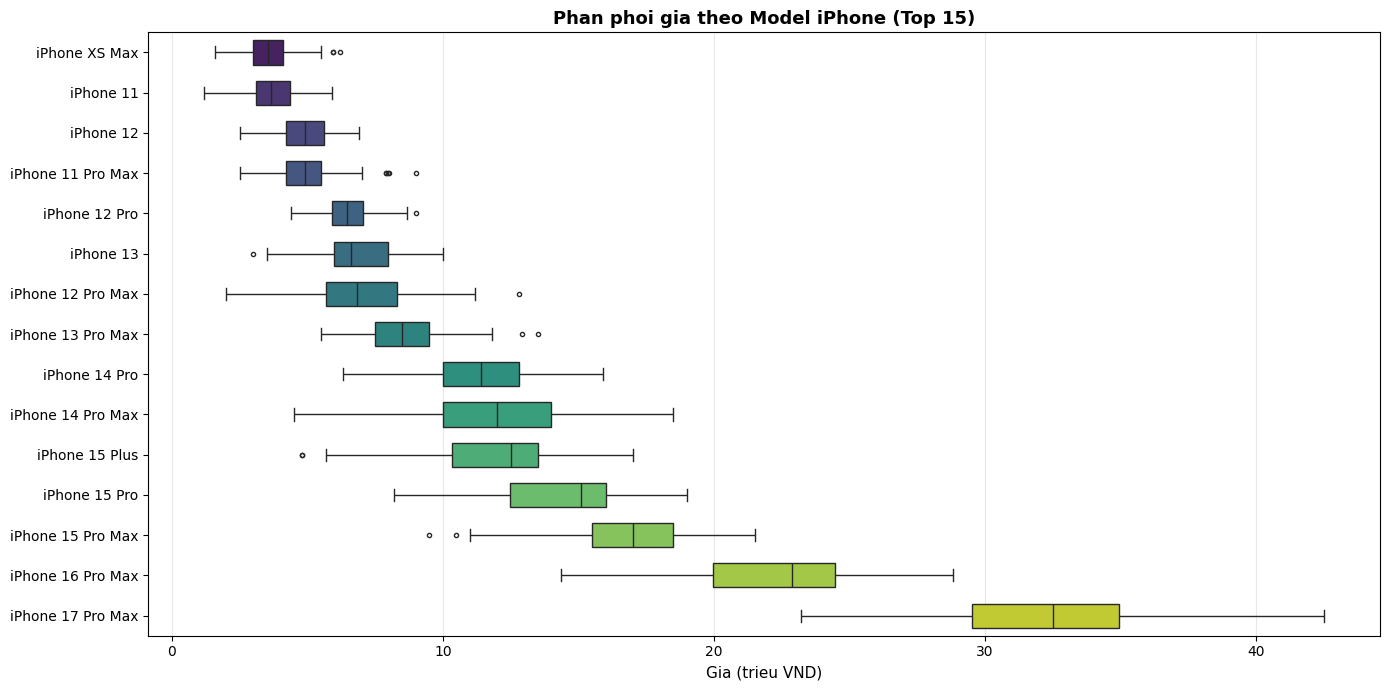

Luu: output/price_by_model_boxplot.png


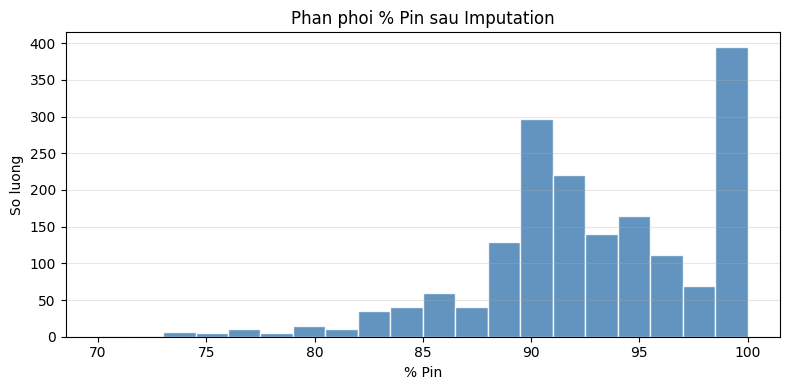

Luu: output/pin_distribution.png


In [9]:
# ============================================================
#  CELL 9 — Visualizations (tuy chon)
# ============================================================
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Boxplot gia theo Model (Top 15)
top_models  = df_out['Dòng máy'].value_counts().head(15).index
df_top      = df_out[df_out['Dòng máy'].isin(top_models)].copy()
df_top['Gia_Trieu'] = df_top['Giá'] / 1e6
model_order = (df_top.groupby('Dòng máy')['Gia_Trieu']
               .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df_top, x='Gia_Trieu', y='Dòng máy',
            order=model_order, palette='viridis',
            width=0.6, fliersize=3, ax=ax)
ax.set_title('Phan phoi gia theo Model iPhone (Top 15)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gia (trieu VND)', fontsize=11)
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('output/price_by_model_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Luu: output/price_by_model_boxplot.png')

# Histogram Pin
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(df['Tinh_Trang_Pin'], bins=20,
         color='steelblue', edgecolor='white', alpha=0.85)
ax2.set_title('Phan phoi % Pin sau Imputation', fontsize=12)
ax2.set_xlabel('% Pin')
ax2.set_ylabel('So luong')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output/pin_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Luu: output/pin_distribution.png')